# C2 — Bidirectional CNN-LSTM — **Perfect Weather + HYSPLIT Forecast**

## Executive Summary
Identical to `B2_hybrid_architecture_perfect_forecast.ipynb` **except**
HYSPLIT features are also shifted to t+h alongside MET_COLS.

**Weather mode:** `"perfect_forecast_full"` — both MET_COLS and all HYSPLIT
columns are shifted by `-max(horizons)=-24` throughout each sequence window.

**Series comparison:**
- A2: weather at t, HYSPLIT at t
- B2: weather at t+24, HYSPLIT at t
- C2: weather at t+24, HYSPLIT at t+24 ← this notebook

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_PATH, TARGET, HORIZONS, SEQ_LEN_LSTM,
    MODEL_DIR, FIGURES_DIR, RESULTS_DIR
)
from src.data_loader import load_data, train_test_split
from src.feature_engineering import build_sequence_dataset, WEATHER_MODE_PERFECT_FULL
from src.models.hybrid_lstm import train_cnn_lstm, predict_cnn_lstm
from src.evaluation import compute_metrics, plot_horizon_metrics, plot_actual_vs_predicted
from src.utils import ensure_dirs, set_seed

WEATHER_MODE = WEATHER_MODE_PERFECT_FULL   # ← only difference from B2

set_seed(42)
ensure_dirs(MODEL_DIR, FIGURES_DIR, RESULTS_DIR)
sns.set_theme(style='whitegrid', palette='tab10')
print(f'Weather mode: {WEATHER_MODE}')

Weather mode: perfect_forecast_full


## 1. Load Data and Build Sequence Datasets

In [2]:
df = load_data(DATA_PATH)
train_df, test_df = train_test_split(df)

X_train_seq, y_train_seq, feature_names, scaler_X = build_sequence_dataset(
    train_df, seq_len=SEQ_LEN_LSTM, horizons=HORIZONS,
    fit_scaler=True, weather_mode=WEATHER_MODE
)
X_test_seq, y_test_seq, _, _ = build_sequence_dataset(
    test_df, seq_len=SEQ_LEN_LSTM, horizons=HORIZONS,
    scaler_X=scaler_X, fit_scaler=False, weather_mode=WEATHER_MODE
)

print(f'Train sequences: X={X_train_seq.shape}, y={y_train_seq.shape}')
print(f'Test  sequences: X={X_test_seq.shape}, y={y_test_seq.shape}')

15:01:47 | src.data_loader | INFO | Loading data from D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv
15:01:47 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48
15:01:47 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00
15:01:47 | src.data_loader | INFO | Train: 43824 rows (2019-01-01 00:00:00 → 2023-12-31 23:00:00)
15:01:47 | src.data_loader | INFO | Test : 8784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)
15:01:47 | src.feature_engineering | INFO | build_sequence_dataset | seq_len=48 | weather_mode=perfect_forecast_full
15:01:47 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -24 h
15:01:47 | src.feature_engineering | INF

Train sequences: X=(37879, 48, 45), y=(37879, 24)
Test  sequences: X=(7709, 48, 45), y=(7709, 24)


## 2. Validation Split

In [3]:
val_size = int(0.1 * len(X_train_seq))
X_tr  = X_train_seq[:-val_size]
y_tr  = y_train_seq[:-val_size]
X_val = X_train_seq[-val_size:]
y_val = y_train_seq[-val_size:]
print(f'Train: {X_tr.shape} | Val: {X_val.shape}')

Train: (34092, 48, 45) | Val: (3787, 48, 45)


## 3. Train CNN-LSTM

In [4]:
model_path = MODEL_DIR / 'cnn_lstm_model_pfx_full.pt'

cnn_lstm_model, history = train_cnn_lstm(
    X_tr, y_tr, X_val, y_val,
    epochs=100, batch_size=64, patience=15, lr=1e-3,
    save_path=model_path
)
print('Training complete.')

15:01:48 | src.models.hybrid_lstm | INFO | Training CNN-LSTM on cpu
15:01:55 | src.models.hybrid_lstm | INFO | CNN-LSTM | seq_len=48  n_features=45  n_horizons=24  device=cpu
15:01:55 | src.models.hybrid_lstm | INFO | Params: epochs=100  batch=64  patience=15  lr=0.00100
15:01:55 | src.models.hybrid_lstm | INFO | Training samples=34092  val samples=3787
15:01:55 | src.models.hybrid_lstm | INFO | -----------------------------------------------------------------
15:02:39 | src.models.hybrid_lstm | INFO | Epoch   1/100  train=0.17334  val=0.06122  best=0.06122  lr=1.00e-03 *
15:03:19 | src.models.hybrid_lstm | INFO | Epoch   2/100  train=0.05815  val=0.05670  best=0.05670  lr=1.00e-03 *
15:03:56 | src.models.hybrid_lstm | INFO | Epoch   3/100  train=0.04359  val=0.05925  best=0.05670  lr=1.00e-03  (no improve 1/15)
15:04:34 | src.models.hybrid_lstm | INFO | Epoch   4/100  train=0.03668  val=0.05576  best=0.05576  lr=1.00e-03 *
15:05:11 | src.models.hybrid_lstm | INFO | Epoch   5/100  trai

Training complete.


## 4. Training Loss Curves

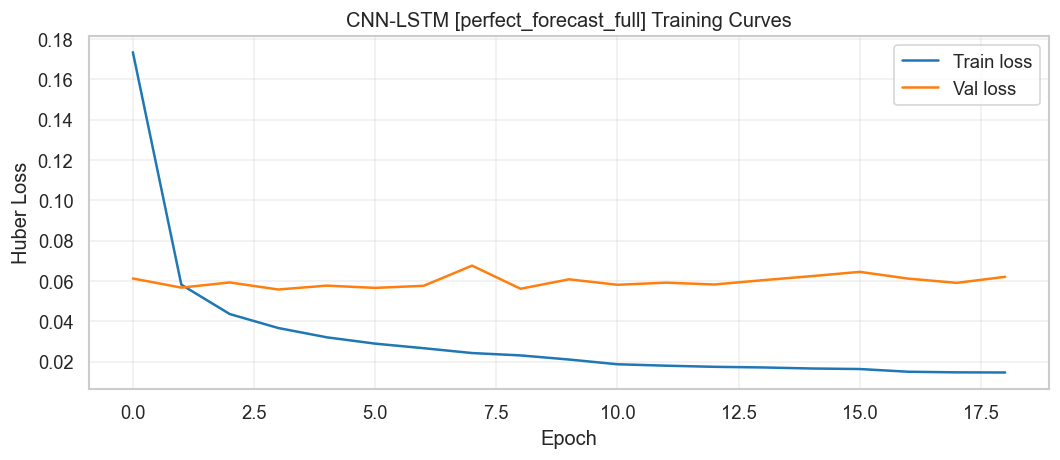

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history['train_loss'], label='Train loss')
ax.plot(history['val_loss'], label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.set_title('CNN-LSTM [perfect_forecast_full] Training Curves')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'C2_loss_curves.png', bbox_inches='tight')
plt.show()

## 5. Evaluate on Test Set

In [6]:
cnn_preds = predict_cnn_lstm(cnn_lstm_model, X_test_seq)
y_test_true = np.expm1(y_test_seq)

results_cnn_full = {}
for h_idx, h in enumerate(HORIZONS):
    results_cnn_full[h] = compute_metrics(y_test_true[:, h_idx], cnn_preds[:, h_idx])

print('CNN-LSTM [perfect_forecast_full] Results:')
for h in [1, 6, 12, 24]:
    m = results_cnn_full[h]
    print(f'  h={h:2d}: MAE={m["MAE"]:.3f}  RMSE={m["RMSE"]:.3f}  R²={m["R2"]:.3f}')

CNN-LSTM [perfect_forecast_full] Results:
  h= 1: MAE=2.675  RMSE=3.738  R²=0.802
  h= 6: MAE=4.275  RMSE=6.177  R²=0.455
  h=12: MAE=4.657  RMSE=6.752  R²=0.348
  h=24: MAE=4.384  RMSE=6.658  R²=0.372


## 6. Three-Series Comparison: A2 vs B2 vs C2

15:13:27 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\C2_vs_B2_vs_A2_mae.png


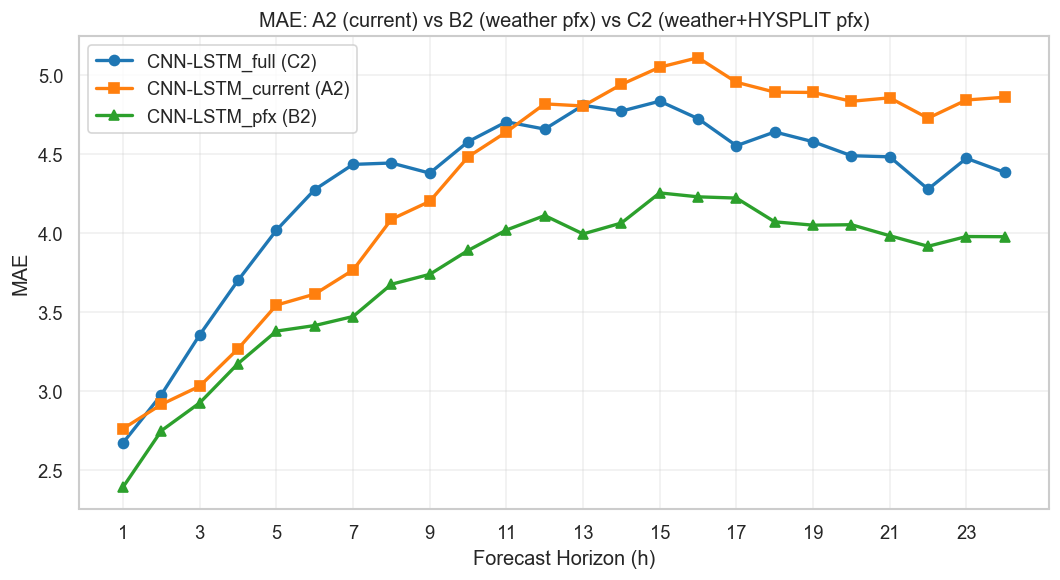

15:13:28 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\C2_vs_B2_vs_A2_r2.png


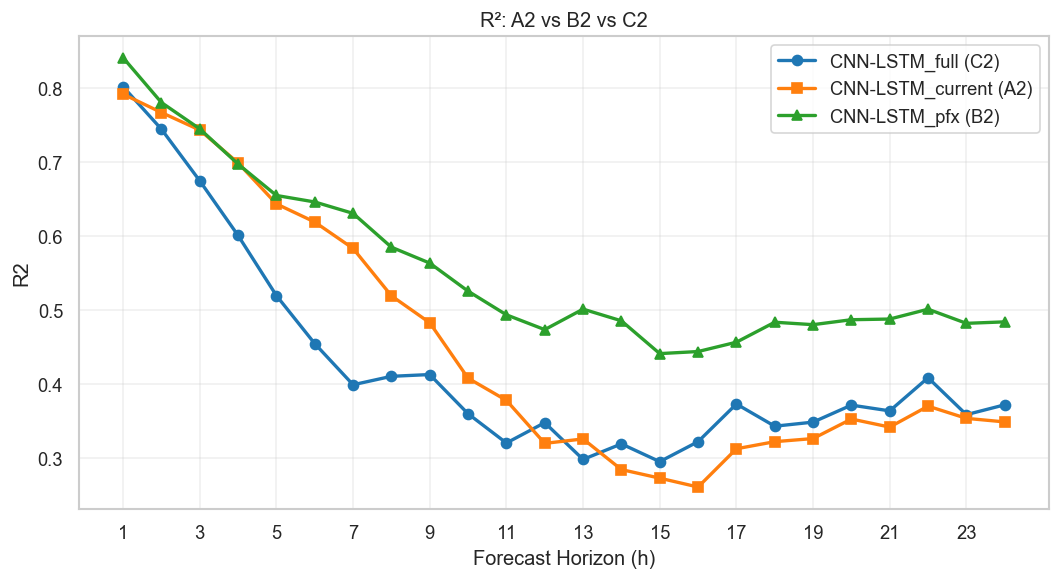

In [7]:
compare = {'CNN-LSTM_full (C2)': results_cnn_full}

for fname, model_label, series_label in [
    ('arch2_metrics.csv', 'Arch2_CNN_LSTM',    'CNN-LSTM_current (A2)'),
    ('B2_metrics.csv',    'B2_CNN_LSTM_pfx',   'CNN-LSTM_pfx (B2)'),
]:
    p = RESULTS_DIR / fname
    if p.exists():
        df_r = pd.read_csv(p)
        sub = df_r[df_r['Model'] == model_label]
        if not sub.empty:
            compare[series_label] = {
                int(r['Horizon']): {'MAE': r['MAE'], 'RMSE': r['RMSE'],
                                    'R2': r['R2'], 'MBE': r['MBE'], 'IA': r['IA']}
                for _, r in sub.iterrows()
            }

fig = plot_horizon_metrics(compare, metric='MAE',
                           save_path=FIGURES_DIR / 'C2_vs_B2_vs_A2_mae.png')
plt.title('MAE: A2 (current) vs B2 (weather pfx) vs C2 (weather+HYSPLIT pfx)')
plt.show()

fig = plot_horizon_metrics(compare, metric='R2',
                           save_path=FIGURES_DIR / 'C2_vs_B2_vs_A2_r2.png')
plt.title('R²: A2 vs B2 vs C2')
plt.show()

## 7. Scatter Plots at Key Horizons

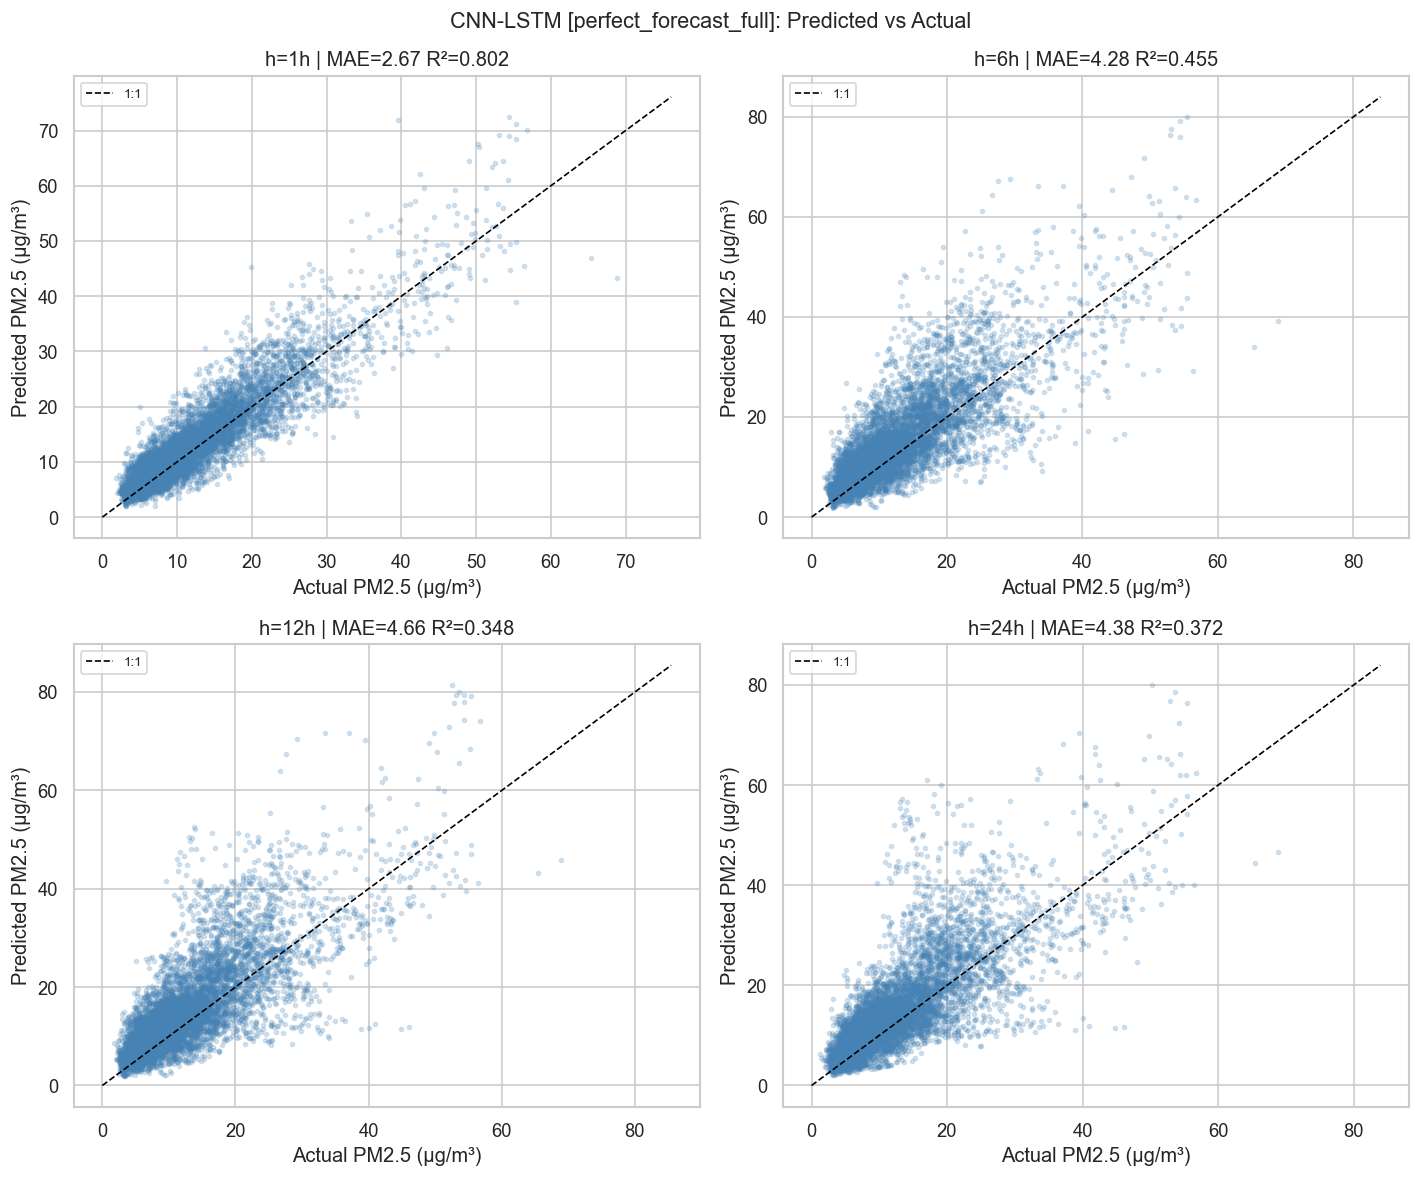

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, h in zip(axes.flat, [1, 6, 12, 24]):
    h_idx = h - 1
    y_t = y_test_true[:, h_idx]
    y_p = cnn_preds[:, h_idx]
    m = results_cnn_full[h]
    ax.scatter(y_t, y_p, alpha=0.2, s=6, color='steelblue')
    lim = max(y_t.max(), y_p.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1')
    ax.set_xlabel('Actual PM2.5 (µg/m³)')
    ax.set_ylabel('Predicted PM2.5 (µg/m³)')
    ax.set_title(f'h={h}h | MAE={m["MAE"]:.2f} R²={m["R2"]:.3f}')
    ax.legend(fontsize=8)
fig.suptitle('CNN-LSTM [perfect_forecast_full]: Predicted vs Actual', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'C2_scatter_plots.png', bbox_inches='tight')
plt.show()

## 8. Save Results

In [9]:
rows = [{'Model': 'C2_CNN_LSTM_full', 'Horizon': h, **m} for h, m in results_cnn_full.items()]
pd.DataFrame(rows).to_csv(RESULTS_DIR / 'C2_metrics.csv', index=False)
print('Saved C2_metrics.csv')

Saved C2_metrics.csv
